

# 3. Portfolio Construction

The strategy ranks eight cryptocurrencies using residual momentum.

At each rebalance:
- Long top 2 assets
- Short bottom 2 assets
- Equal weighted
- 7-day holding period
- Transaction costs applied based on turnover

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "crypto_hourly_clean_2020_2025.csv",
    parse_dates=["open_time"]
)

dev = df[
    (df["open_time"] >= "2020-01-01") &
    (df["open_time"] < "2024-01-01")
].copy()

return_panel = (
    dev
    .pivot(
        index="open_time",
        columns="symbol",
        values="ret_1h"
    )
    .sort_index()
)

print("Development shape:", return_panel.shape)
display(return_panel.head())

Development shape: (35033, 8)


symbol,ADAUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,ETHUSDT,LINKUSDT,LTCUSDT,XRPUSDT
open_time,,,,,,,,
2020-01-01 00:00:00+00:00,-0.002131,-0.001312,-0.002531,-0.002583,-0.002245,-0.001980,-0.000484,-0.002436
2020-01-01 01:00:00+00:00,0.006406,0.007402,0.005469,0.005577,0.013735,0.010942,0.008236,0.006390
2020-01-01 02:00:00+00:00,0.005456,0.003500,0.003683,0.004803,0.001607,0.009702,0.005526,0.002426
2020-01-01 03:00:00+00:00,-0.004221,-0.002224,-0.002463,-0.009610,-0.004968,-0.003999,-0.007646,-0.001081
2020-01-01 04:00:00+00:00,-0.001211,-0.001795,-0.001071,0.001642,0.000000,0.002008,0.001445,-0.001753


In [3]:
# Step 3: Reconstruct residual returns

market_return = return_panel.mean(axis=1)

beta_window = 24 * 30

market_var = market_return.rolling(
    beta_window,
    min_periods=beta_window
).var()

rolling_beta = pd.DataFrame(
    index=return_panel.index,
    columns=return_panel.columns,
    dtype=float
)

for asset in return_panel.columns:

    rolling_cov = (
        return_panel[asset]
        .rolling(
            beta_window,
            min_periods=beta_window
        )
        .cov(market_return)
    )

    rolling_beta[asset] = rolling_cov / market_var

market_component = rolling_beta.mul(
    market_return,
    axis=0
)

residual_return = (
    return_panel - market_component
)

print("Residual return shape:", residual_return.shape)

Residual return shape: (35033, 8)


In [4]:
# Step 4: Generic residual long-short strategy

def build_residual_strategy(
    residual_return,
    raw_return,
    formation_h,
    holding_h,
    breadth=2,
    direction="momentum"
):

    # Formation signal
    signal = (
        residual_return
        .rolling(
            window=formation_h,
            min_periods=formation_h
        )
        .sum()
    )

    # Future compounded raw returns
    future_return = (
        (1 + raw_return)
        .rolling(window=holding_h)
        .apply(np.prod, raw=True)
        .shift(-holding_h)
        - 1
    )

    # Rebalance every holding_h hours
    rebalance_times = signal.index[
        formation_h::holding_h
    ]

    signal = signal.loc[rebalance_times]
    future_return = future_return.loc[rebalance_times]

    weights = pd.DataFrame(
        0.0,
        index=rebalance_times,
        columns=signal.columns
    )

    for t in rebalance_times:

        s = signal.loc[t].dropna()

        if len(s) < 2 * breadth:
            continue

        if direction == "momentum":

            long_assets = s.nlargest(breadth).index
            short_assets = s.nsmallest(breadth).index

        elif direction == "reversal":

            long_assets = s.nsmallest(breadth).index
            short_assets = s.nlargest(breadth).index

        else:
            raise ValueError(
                "direction must be 'momentum' or 'reversal'"
            )

        # Dollar-neutral
        weights.loc[t, long_assets] = 0.5 / breadth
        weights.loc[t, short_assets] = -0.5 / breadth

    # Gross return
    gross_return = (
        weights * future_return
    ).sum(axis=1)

    active = (
        weights.abs().sum(axis=1) > 0
    )

    return {
        "signal": signal.loc[active],
        "weights": weights.loc[active],
        "future_return": future_return.loc[active],
        "gross_return": gross_return.loc[active]
    }

In [5]:
# Candidate A: Residual Momentum

momentum_strategy = build_residual_strategy(
    residual_return=residual_return,
    raw_return=return_panel,
    formation_h=336,
    holding_h=168,
    breadth=2,
    direction="momentum"
)

print(
    "Momentum periods:",
    len(momentum_strategy["gross_return"])
)

display(
    momentum_strategy["weights"].head()
)

display(
    momentum_strategy["gross_return"].describe()
)

Momentum periods: 136


symbol,ADAUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,ETHUSDT,LINKUSDT,LTCUSDT,XRPUSDT
open_time,,,,,,,,
2020-04-22 07:00:00+00:00,0.00,0.00,0.00,0.00,0.25,0.25,-0.25,-0.25
2020-06-10 09:00:00+00:00,0.25,0.00,0.00,-0.25,0.25,0.00,0.00,-0.25
2020-06-17 09:00:00+00:00,0.25,-0.25,0.25,0.00,0.00,-0.25,0.00,0.00
2020-06-24 09:00:00+00:00,0.25,-0.25,0.00,0.00,0.00,0.25,0.00,-0.25
2020-08-12 12:00:00+00:00,-0.25,0.00,0.00,-0.25,0.25,0.25,0.00,0.00


count    136.000000
mean       0.004341
std        0.037215
min       -0.154691
25%       -0.015891
50%        0.001029
75%        0.020878
max        0.158175
dtype: float64

In [6]:
# Candidate B: Residual Reversal

reversal_strategy = build_residual_strategy(
    residual_return=residual_return,
    raw_return=return_panel,
    formation_h=72,
    holding_h=24,
    breadth=2,
    direction="reversal"
)

print(
    "Reversal periods:",
    len(reversal_strategy["gross_return"])
)

display(
    reversal_strategy["weights"].head()
)

display(
    reversal_strategy["gross_return"].describe()
)

Reversal periods: 1053


symbol,ADAUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,ETHUSDT,LINKUSDT,LTCUSDT,XRPUSDT
open_time,,,,,,,,
2020-02-03 00:00:00+00:00,0.0,0.0,0.25,0.00,0.00,0.25,-0.25,-0.25
2020-02-04 00:00:00+00:00,0.0,0.0,0.25,0.00,-0.25,0.25,0.00,-0.25
2020-02-05 00:00:00+00:00,0.0,0.0,0.00,-0.25,0.00,0.25,0.25,-0.25
2020-02-06 00:00:00+00:00,0.0,0.0,0.00,0.00,-0.25,0.25,0.25,-0.25
2020-02-07 00:00:00+00:00,0.0,0.0,0.00,-0.25,-0.25,0.25,0.25,0.00


count    1053.000000
mean       -0.001488
std         0.025149
min        -0.328702
25%        -0.007804
50%        -0.000159
75%         0.006423
max         0.388001
dtype: float64

In [7]:
def performance_summary(
    strategy_result,
    holding_h
):

    r = strategy_result["gross_return"].dropna()

    periods_per_year = 365 * 24 / holding_h

    annual_return = (
        r.mean() * periods_per_year
    )

    annual_vol = (
        r.std() * np.sqrt(periods_per_year)
    )

    sharpe = (
        annual_return / annual_vol
        if annual_vol > 0 else np.nan
    )

    equity = (1 + r).cumprod()
    running_max = equity.cummax()

    max_drawdown = (
        equity / running_max - 1
    ).min()

    return {
        "annual_return": annual_return,
        "annual_vol": annual_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown
    }

In [8]:
momentum_perf = performance_summary(
    momentum_strategy,
    holding_h=168
)

reversal_perf = performance_summary(
    reversal_strategy,
    holding_h=24
)

gross_comparison = pd.DataFrame([
    {
        "strategy": "Residual Momentum",
        **momentum_perf
    },
    {
        "strategy": "Residual Reversal",
        **reversal_perf
    }
])

display(
    gross_comparison.round(4)
)

,strategy,annual_return,annual_vol,sharpe,max_drawdown
0,Residual Momentum,0.2264,0.2687,0.8424,-0.1778
1,Residual Reversal,-0.5430,0.4805,-1.1303,-0.8601


In [9]:
# Step 8: Check momentum rebalance schedule

momentum_dates = momentum_strategy["gross_return"].index

date_gaps = (
    momentum_dates
    .to_series()
    .diff()
    .dt.total_seconds()
    / 3600
)

print("Number of strategy periods:", len(momentum_dates))

print("\nRebalance gap distribution (hours):")
display(
    date_gaps.value_counts()
    .sort_index()
    .head(20)
)

print("\nLargest gaps:")
display(
    date_gaps.sort_values(
        ascending=False
    ).head(10)
)

Number of strategy periods: 136

Rebalance gap distribution (hours):


open_time
168.0     129
1177.0      1
1178.0      1
1179.0      1
1853.0      1
2358.0      1
2863.0      1
Name: count, dtype: int64


Largest gaps:


open_time
2021-06-10 00:00:00+00:00    2863.0
2021-11-18 06:00:00+00:00    2358.0
2021-02-10 17:00:00+00:00    1853.0
2020-08-12 12:00:00+00:00    1179.0
2020-06-10 09:00:00+00:00    1178.0
2023-05-11 07:00:00+00:00    1177.0
2022-09-29 06:00:00+00:00     168.0
2022-10-06 06:00:00+00:00     168.0
2023-03-23 06:00:00+00:00     168.0
2023-03-16 06:00:00+00:00     168.0
Name: open_time, dtype: float64

In [10]:
# Step 8.1: Check data availability by asset

availability = []

for asset in return_panel.columns:
    
    s = return_panel[asset].dropna()
    
    availability.append({
        "asset": asset,
        "first_date": s.index.min(),
        "last_date": s.index.max(),
        "n_obs": len(s),
        "missing_pct": return_panel[asset].isna().mean()
    })

availability_table = pd.DataFrame(availability)

display(availability_table)

,asset,first_date,last_date,n_obs,missing_pct
0,ADAUSDT,2020-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00,35018,0.000428
1,BNBUSDT,2020-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00,35018,0.000428
2,BTCUSDT,2020-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00,35018,0.000428
3,DOGEUSDT,2020-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00,35018,0.000428
4,ETHUSDT,2020-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00,35018,0.000428
5,LINKUSDT,2020-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00,35018,0.000428
6,LTCUSDT,2020-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00,35018,0.000428
7,XRPUSDT,2020-01-01 00:00:00+00:00,2023-12-31 23:00:00+00:00,35018,0.000428


In [11]:
# Step 8.2: Number of available assets through time

available_assets = return_panel.notna().sum(axis=1)

print("Available asset count distribution:")

display(
    available_assets
    .value_counts()
    .sort_index()
)

print("\nMinimum available assets:", available_assets.min())
print("Maximum available assets:", available_assets.max())

Available asset count distribution:


0       15
8    35018
Name: count, dtype: int64


Minimum available assets: 0
Maximum available assets: 8


In [12]:
# Reconstruct 336h residual momentum signal

signal_336 = (
    residual_return
    .rolling(
        window=336,
        min_periods=336
    )
    .sum()
)

print("336h residual momentum signal:")
print("Total rows:", len(signal_336))
print(
    "Rows with all 8 signals available:",
    signal_336.notna().all(axis=1).sum()
)

336h residual momentum signal:
Total rows: 35033
Rows with all 8 signals available: 22760


In [13]:
# Step 8.4: Inspect gaps in valid 336h signal

valid_signal = signal_336.notna().all(axis=1)
valid_times = signal_336.index[valid_signal]

signal_gaps = (
    valid_times.to_series()
    .diff()
    .dt.total_seconds()
    / 3600
)

print("Valid signal observations:", valid_signal.sum())

print("\nGap distribution:")
display(
    signal_gaps
    .value_counts()
    .sort_index()
    .head(20)
)

print("\nLargest gaps:")
display(
    signal_gaps
    .sort_values(ascending=False)
    .head(15)
)

Valid signal observations: 22760

Gap distribution:


open_time
1.0       22751
1057.0        1
1058.0        2
1059.0        1
1060.0        1
1182.0        1
1607.0        1
1653.0        1
Name: count, dtype: int64


Largest gaps:


open_time
2021-02-07 02:00:00+00:00    1653.0
2021-04-19 02:00:00+00:00    1607.0
2021-06-08 07:00:00+00:00    1182.0
2021-09-26 05:00:00+00:00    1060.0
2020-08-11 04:00:00+00:00    1059.0
2021-11-12 08:00:00+00:00    1058.0
2020-06-08 03:00:00+00:00    1058.0
2023-05-07 13:00:00+00:00    1057.0
2020-04-17 11:00:00+00:00       1.0
2023-01-06 00:00:00+00:00       1.0
2023-01-05 23:00:00+00:00       1.0
2023-01-05 22:00:00+00:00       1.0
2023-01-05 21:00:00+00:00       1.0
2023-01-05 20:00:00+00:00       1.0
2023-01-05 19:00:00+00:00       1.0
Name: open_time, dtype: float64

In [14]:
# Step 8.5: Recalculate rolling beta with 95% minimum coverage

beta_window = 720
beta_min_obs = int(beta_window * 0.95)   # 684

market_return = return_panel.mean(axis=1)

market_var_fixed = (
    market_return
    .rolling(
        window=beta_window,
        min_periods=beta_min_obs
    )
    .var()
)

rolling_beta_fixed = pd.DataFrame(
    index=return_panel.index,
    columns=return_panel.columns,
    dtype=float
)

for asset in return_panel.columns:

    rolling_cov_fixed = (
        return_panel[asset]
        .rolling(
            window=beta_window,
            min_periods=beta_min_obs
        )
        .cov(market_return)
    )

    rolling_beta_fixed[asset] = (
        rolling_cov_fixed / market_var_fixed
    )

In [15]:
# Step 8.6: Recalculate residual returns

market_component_fixed = rolling_beta_fixed.mul(
    market_return,
    axis=0
)

residual_return_fixed = (
    return_panel - market_component_fixed
)

print(
    "Valid residual rows:",
    residual_return_fixed.notna().all(axis=1).sum()
)

Valid residual rows: 34335


In [16]:
# Step 8.7: Recalculate 336h residual momentum signal

signal_window = 336
signal_min_obs = int(signal_window * 0.95)   # 319

signal_336_fixed = (
    residual_return_fixed
    .rolling(
        window=signal_window,
        min_periods=signal_min_obs
    )
    .sum()
)

print(
    "Valid 336h signal rows:",
    signal_336_fixed.notna().all(axis=1).sum()
)

Valid 336h signal rows: 34031


In [17]:
valid_signal_fixed = signal_336_fixed.notna().all(axis=1)

valid_times_fixed = signal_336_fixed.index[
    valid_signal_fixed
]

signal_gaps_fixed = (
    valid_times_fixed.to_series()
    .diff()
    .dt.total_seconds()
    / 3600
)

print("Gap distribution:")

display(
    signal_gaps_fixed
    .value_counts()
    .sort_index()
    .head(20)
)

print("\nLargest gaps:")

display(
    signal_gaps_fixed
    .sort_values(ascending=False)
    .head(15)
)

Gap distribution:


open_time
1.0    34016
2.0        6
3.0        3
4.0        3
5.0        1
6.0        1
Name: count, dtype: int64


Largest gaps:


open_time
2020-02-19 17:00:00+00:00    6.0
2021-08-13 06:00:00+00:00    5.0
2021-04-25 08:00:00+00:00    4.0
2020-12-21 18:00:00+00:00    4.0
2020-06-28 05:00:00+00:00    4.0
2020-04-25 04:00:00+00:00    3.0
2021-04-20 04:00:00+00:00    3.0
2021-09-29 09:00:00+00:00    3.0
2021-03-06 03:00:00+00:00    2.0
2023-03-24 14:00:00+00:00    2.0
2021-02-11 05:00:00+00:00    2.0
2020-03-04 11:00:00+00:00    2.0
2020-12-25 03:00:00+00:00    2.0
2020-11-30 07:00:00+00:00    2.0
2022-09-15 15:00:00+00:00    1.0
Name: open_time, dtype: float64

In [18]:
# Step 9: Rebuild fixed residual momentum strategy

holding_h = 168
breadth = 2

# Future 168h compounded raw return
future_168 = (
    (1 + return_panel)
    .rolling(window=holding_h)
    .apply(np.prod, raw=True)
    .shift(-holding_h)
    - 1
)

# Rebalance every 168 hours
rebalance_times = signal_336_fixed.index[
    336::holding_h
]

signal = signal_336_fixed.loc[rebalance_times]
future_return = future_168.loc[rebalance_times]

weights_fixed = pd.DataFrame(
    0.0,
    index=rebalance_times,
    columns=return_panel.columns
)

for t in rebalance_times:

    s = signal.loc[t].dropna()

    if len(s) < 2 * breadth:
        continue

    # Residual momentum
    long_assets = s.nlargest(breadth).index
    short_assets = s.nsmallest(breadth).index

    weights_fixed.loc[t, long_assets] = 0.5 / breadth
    weights_fixed.loc[t, short_assets] = -0.5 / breadth

gross_return_fixed = (
    weights_fixed * future_return
).sum(axis=1)

active = weights_fixed.abs().sum(axis=1) > 0

weights_fixed = weights_fixed.loc[active]
gross_return_fixed = gross_return_fixed.loc[active]

print("Strategy periods:", len(gross_return_fixed))
display(weights_fixed.head())
display(gross_return_fixed.describe())

Strategy periods: 203


symbol,ADAUSDT,BNBUSDT,BTCUSDT,DOGEUSDT,ETHUSDT,LINKUSDT,LTCUSDT,XRPUSDT
open_time,,,,,,,,
2020-02-12 01:00:00+00:00,-0.25,0.00,-0.25,0.00,0.25,0.25,0.00,0.00
2020-02-19 01:00:00+00:00,-0.25,0.00,0.00,0.00,0.25,0.25,-0.25,0.00
2020-02-26 06:00:00+00:00,0.00,-0.25,0.00,-0.25,0.25,0.25,0.00,0.00
2020-03-04 06:00:00+00:00,0.00,0.00,-0.25,0.25,0.00,0.25,0.00,-0.25
2020-03-11 07:00:00+00:00,-0.25,0.00,0.00,0.25,0.00,0.25,-0.25,0.00


count    203.000000
mean       0.008466
std        0.052638
min       -0.154691
25%       -0.017199
50%        0.000000
75%        0.020971
max        0.297969
dtype: float64

In [19]:
# Step 10: Gross performance after data-coverage fix

r = gross_return_fixed.dropna()

periods_per_year = 365 * 24 / 168

annual_return = r.mean() * periods_per_year
annual_vol = r.std() * np.sqrt(periods_per_year)

gross_sharpe = (
    annual_return / annual_vol
    if annual_vol > 0 else np.nan
)

equity_curve = (1 + r).cumprod()
running_max = equity_curve.cummax()

max_drawdown = (
    equity_curve / running_max - 1
).min()

print("Annualised return:",
      round(annual_return, 4))

print("Annualised volatility:",
      round(annual_vol, 4))

print("Gross Sharpe:",
      round(gross_sharpe, 4))

print("Maximum Drawdown:",
      round(max_drawdown, 4))

Annualised return: 0.4414
Annualised volatility: 0.3801
Gross Sharpe: 1.1614
Maximum Drawdown: -0.2234


In [20]:
# Step 11: Calculate portfolio turnover

turnover = (
    weights_fixed
    .diff()
    .abs()
    .sum(axis=1)
)

# First portfolio formation
turnover.iloc[0] = weights_fixed.iloc[0].abs().sum()

print("Turnover summary:")
display(turnover.describe())

print("Average turnover:",
      round(turnover.mean(), 7))

print("Median turnover:",
      round(turnover.median(), 7))

Turnover summary:


count    203.000000
mean       1.019704
std        0.460957
min        0.000000
25%        0.500000
50%        1.000000
75%        1.500000
max        2.000000
dtype: float64

Average turnover: 1.0197044
Median turnover: 1.0


In [21]:
# Step 12: Apply 7 bps transaction cost

cost_bps = 7
cost_rate = cost_bps / 10000

transaction_cost = turnover * cost_rate

net_return = gross_return_fixed - transaction_cost

print("Cost assumption:", cost_bps, "bps")
print("Average turnover:", round(turnover.mean(), 4))
print("Average transaction cost per rebalance:",
      round(transaction_cost.mean(), 6))

display(net_return.describe())

Cost assumption: 7 bps
Average turnover: 1.0197
Average transaction cost per rebalance: 0.000714


count    203.000000
mean       0.007752
std        0.052635
min       -0.155041
25%       -0.017724
50%       -0.000350
75%        0.020136
max        0.296919
dtype: float64

In [22]:
# Step 12.1: Net performance after transaction costs

r_net = net_return.dropna()

periods_per_year = 365 * 24 / 168

annual_return_net = (
    r_net.mean() * periods_per_year
)

annual_vol_net = (
    r_net.std() * np.sqrt(periods_per_year)
)

net_sharpe = (
    annual_return_net / annual_vol_net
    if annual_vol_net > 0 else np.nan
)

equity_net = (1 + r_net).cumprod()
running_max_net = equity_net.cummax()

max_drawdown_net = (
    equity_net / running_max_net - 1
).min()

print("Net annualised return:",
      round(annual_return_net, 4))

print("Net annualised volatility:",
      round(annual_vol_net, 4))

print("Net Sharpe:",
      round(net_sharpe, 4))

print("Net Maximum Drawdown:",
      round(max_drawdown_net, 4))

Net annualised return: 0.4042
Net annualised volatility: 0.3801
Net Sharpe: 1.0635
Net Maximum Drawdown: -0.2391


In [23]:
# Step 13: Year-by-year net performance

yearly_results = []

for year in sorted(r_net.index.year.unique()):

    r_year = r_net[r_net.index.year == year]

    # Number of actual strategy observations
    n = len(r_year)

    if n < 2:
        continue

    # Annualisation based on weekly strategy
    periods_per_year = 365 * 24 / 168

    annual_return = r_year.mean() * periods_per_year

    annual_vol = (
        r_year.std() * np.sqrt(periods_per_year)
    )

    sharpe = (
        annual_return / annual_vol
        if annual_vol > 0 else np.nan
    )

    equity = (1 + r_year).cumprod()
    running_max = equity.cummax()

    max_drawdown = (
        equity / running_max - 1
    ).min()

    yearly_results.append({
        "year": year,
        "n_periods": n,
        "annual_return": annual_return,
        "annual_vol": annual_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown
    })


yearly_performance = pd.DataFrame(yearly_results)

display(
    yearly_performance.round(4)
)

,year,n_periods,annual_return,annual_vol,sharpe,max_drawdown
0,2020,47,0.3568,0.2941,1.2130,-0.1503
1,2021,52,1.0782,0.5810,1.8557,-0.1738
2,2022,52,0.1942,0.2855,0.6801,-0.1163
3,2023,52,-0.0169,0.2485,-0.0679,-0.2391


# result
Residual momentum strategy was profitable after 7 bps transaction costs during 2020–2022, but performance deteriorated materially in 2023, indicating time-varying signal strength and potential regime dependence.

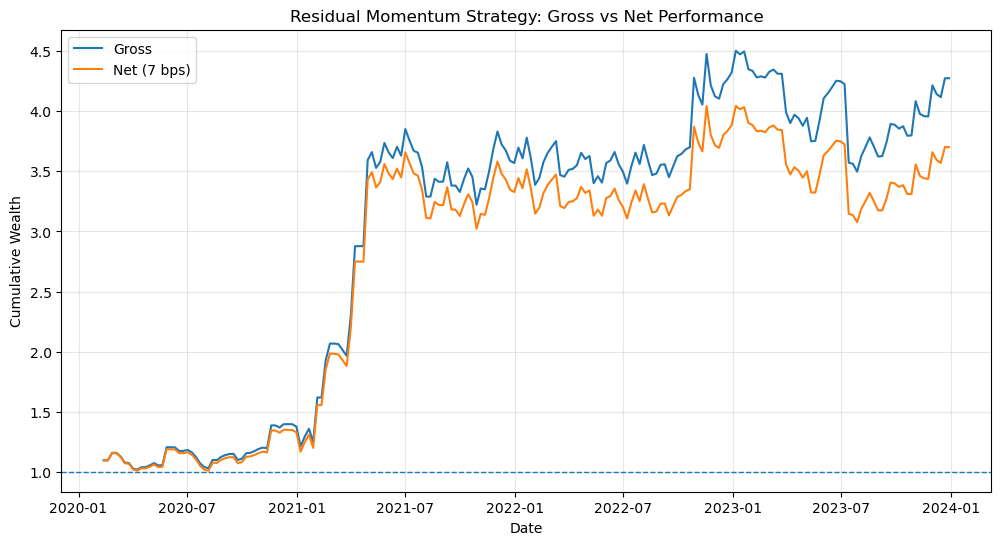

In [25]:
# Step 14: Plot gross vs net equity curves

import matplotlib.pyplot as plt

gross_equity = (
    1 + gross_return_fixed.dropna()
).cumprod()

net_equity = (
    1 + net_return.dropna()
).cumprod()

plt.figure(figsize=(12, 6))

plt.plot(
    gross_equity.index,
    gross_equity,
    label="Gross"
)

plt.plot(
    net_equity.index,
    net_equity,
    label="Net (7 bps)"
)

plt.axhline(
    1,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Residual Momentum Strategy: Gross vs Net Performance"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Wealth")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [26]:
# Step 15: Equal-weight crypto benchmark

benchmark_hourly = return_panel.mean(axis=1)

# Convert hourly benchmark returns
# to the same 168h strategy frequency

benchmark_168h = (
    (1 + benchmark_hourly)
    .rolling(168)
    .apply(np.prod, raw=True)
    - 1
)

# Align benchmark with strategy dates
benchmark_168h = benchmark_168h.reindex(
    r_net.index
)

benchmark_168h = benchmark_168h.dropna()

print("Benchmark observations:",
      len(benchmark_168h))

display(
    benchmark_168h.describe()
)

Benchmark observations: 188


count    188.000000
mean       0.021111
std        0.130574
min       -0.429446
25%       -0.044859
50%        0.014227
75%        0.073126
max        0.703910
dtype: float64

In [27]:
# Step 15.1: Benchmark performance

r_bench = benchmark_168h.dropna()

periods_per_year = 365 * 24 / 168

# Annualised return
bench_annual_return = (
    r_bench.mean() * periods_per_year
)

# Annualised volatility
bench_annual_vol = (
    r_bench.std() * np.sqrt(periods_per_year)
)

# Sharpe ratio
bench_sharpe = (
    bench_annual_return / bench_annual_vol
    if bench_annual_vol > 0
    else np.nan
)

# Equity curve
bench_equity = (
    1 + r_bench
).cumprod()

# Maximum Drawdown
bench_running_max = bench_equity.cummax()

bench_max_drawdown = (
    bench_equity / bench_running_max - 1
).min()

print(
    "Benchmark annualised return:",
    round(bench_annual_return, 4)
)

print(
    "Benchmark annualised volatility:",
    round(bench_annual_vol, 4)
)

print(
    "Benchmark Sharpe:",
    round(bench_sharpe, 4)
)

print(
    "Benchmark Maximum Drawdown:",
    round(bench_max_drawdown, 4)
)

Benchmark annualised return: 1.1008
Benchmark annualised volatility: 0.9429
Benchmark Sharpe: 1.1675
Benchmark Maximum Drawdown: -0.7445


In [29]:

import statsmodels.api as sm

r = r_net.dropna()

X = np.ones(len(r))

model = sm.OLS(r.values, X).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 7}
)

print("Observations:", len(r))
print("Mean return per rebalance:", r.mean())
print("Newey-West t-stat:", model.tvalues[0])
print("p-value:", model.pvalues[0])

Observations: 203
Mean return per rebalance: 0.007751967481194505
Newey-West t-stat: 1.9562239616249621
p-value: 0.05043877700066411
